# Retail Sales EDA
## Project Overview.
Analysis of Superstore retail sales data (obtained from [Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)) to understand revenue performance,
product category trends, regional distribution, and the impact of discounts on profitability.

## Project Business Questions.
1. What does the data look like?
2. What is the overall sales and profit performance?
3. Which product categories and sub-categories drive the most revenue and profit?
4. How do sales vary across regions?
5. Is there a relationship between discount and profit?
6. How have sales trended over time?

In [1]:
# import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All packages imported successfully")
# print(f"pandas version: {pd.__version__}")

All packages imported successfully


## Initial data inspection.

In [2]:
# load Superstore dataset
# data not encoded in UTF-8, so latin-1 encoding is used
ss_df = pd.read_csv('../data/superstore.csv', encoding='latin-1')
print('Dataset loaded successfully')

# check the shape of the dataset
print(f'Dataset shape: {ss_df.shape}')

Dataset loaded successfully
Dataset shape: (9994, 21)


In [3]:
# show the first few rows of the dataset
ss_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#check column names and data types
ss_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
# check for missing values
print(f'Missing values in each column:\n{ss_df.isna().sum()}')

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## What is the overall sales and profit performance?

In [6]:
# total sales across all orders
total_sales = ss_df['Sales'].sum()
print(f'Total sales across all orders: ${total_sales:,.2f}\n')

# total profit across all orders
total_profit = ss_df['Profit'].sum()
print(f'Total profit across all orders: ${total_profit:,.2f}\n')

# average order sale value
avg_sale_order = ss_df['Sales'].mean()
print(f'Average order sale value: ${avg_sale_order:,.2f}\n')

# average profit per order
avg_profit_order = ss_df['Profit'].mean()
print(f'Average profit per order: ${avg_profit_order:,.2f}\n')

# overall profit margin 
profit_margin = (total_profit / total_sales) * 100
print(f'Overall profit margin: {profit_margin:.2f}%')

Total sales across all orders: $2,297,200.86

Total profit across all orders: $286,397.02

Average order sale value: $229.86

Average profit per order: $28.66

Overall profit margin: 12.47%


### Interpretation
The superstore recorded a total sale amount of \$2,297,200.86 across all orders. The total profit amounted to \$286,397.02 demonstrating a 12.47\% profit margin which is above the retail industry average (~3-10\%) suggesting that the company is making good pricing decisions. However, the average sale on an order is \$229.86 with an average profit of \$28.66 which suggests that the average transaction is on a moderate scale. We can investigate further to uncover what accounts for this profit per order amount.

## Which product categories and sub-categories drive the most revenue and profit?

In [18]:
# sort the dataset by profit in descending order
revenue_by_category = ss_df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().round(2)

sorted_revenue_by_category = revenue_by_category.sort_values(by='Profit', ascending=False)
sorted_revenue_by_category

Sales    Profit
Category        Sub-Category                     
Technology      Copiers       149528.03  55617.82
                Phones        330007.05  44515.73
                Accessories   167380.32  41936.64
Office Supplies Paper          78479.21  34053.57
                Binders       203412.73  30221.76
Furniture       Chairs        328449.10  26590.17
Office Supplies Storage       223843.61  21278.83
                Appliances    107532.16  18138.01
Furniture       Furnishings    91705.16  13059.14
Office Supplies Envelopes      16476.40   6964.18
                Art            27118.79   6527.79
                Labels         12486.31   5546.25
Technology      Machines      189238.63   3384.76
Office Supplies Fasteners       3024.28    949.52
                Supplies       46673.54  -1189.10
Furniture       Bookcases     114880.00  -3472.56
                Tables        206965.53 -17725.48

In [19]:
# reset index to make 'Sub-Category' a column again, then set it as the index for plotting
sorted_revenue_by_category_reset = sorted_revenue_by_category.reset_index().set_index('Sub-Category')
sorted_revenue_by_category_reset

,Category,Sales,Profit
Sub-Category,,,
Copiers,Technology,149528.03,55617.82
Phones,Technology,330007.05,44515.73
Accessories,Technology,167380.32,41936.64
Paper,Office Supplies,78479.21,34053.57
Binders,Office Supplies,203412.73,30221.76
Chairs,Furniture,328449.10,26590.17
Storage,Office Supplies,223843.61,21278.83
Appliances,Office Supplies,107532.16,18138.01
Furnishings,Furniture,91705.16,13059.14


<Axes: title={'center': 'Profit by Sub-Category'}, xlabel='Profit ($)', ylabel='Sub-Category'>

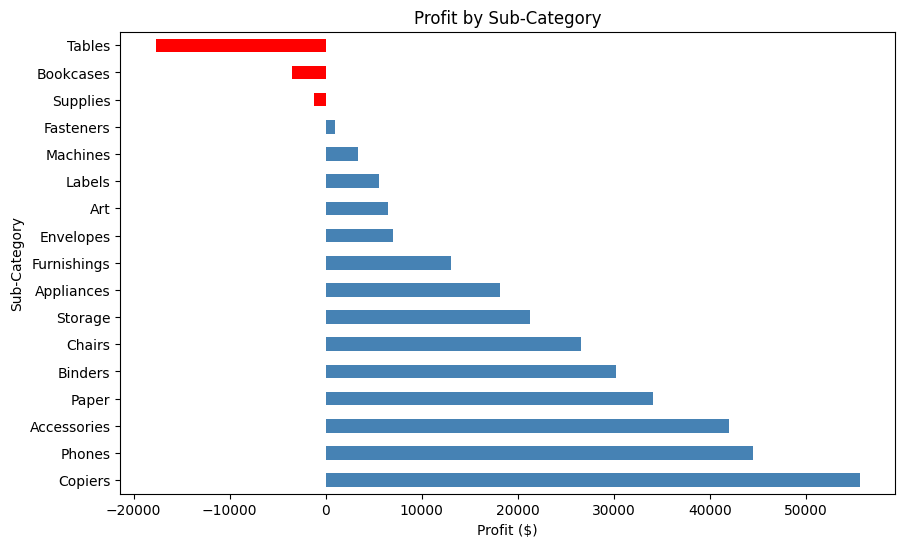

In [9]:
# create a horizontal bar plot with different colors for positive and negative profit values
colorlist = ['steelblue' if profit >= 0 else 'red' for profit in sorted_revenue_by_category_reset['Profit']]
sorted_revenue_by_category_reset.plot(kind='barh', y = 'Profit', figsize = (10,6), legend = False, color = colorlist,
                                      title = 'Profit by Sub-Category',  xlabel = 'Profit ($)', ylabel = 'Sub-Category')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.savefig('../reports/profit_by_subcategory.png', bbox_inches='tight', dpi=150)

### Interpretation
The analysis shows that the Technology category is the top profit driver, led by Copiers (~$56K), Phones (~$45K), and Accessories (~$42K). Tables is the least profitable sub-category with ~$17K in losses despite high sales records, suggesting possible pricing or cost management issues. The Office Supplies category is driven by Paper (~$34K) and Binders (~$30K). Furniture is driven by Chairs (~$27K) but has the least profitable sub-categories, also despite reasonably high sales volume. This suggests that the company may stand to make more profit by reevaluating pricing and cost management strategies regarding these categories.

## How do sales and profit vary across regions?

In [20]:
# group sales by regions and calculate total sales and profit for each region
sales_by_region = ss_df.groupby('Region')[['Sales', 'Profit']].sum().round(2)

# sort the sales by region in descending order
sales_by_region_sorted = sales_by_region.sort_values(by='Sales', ascending = False)
sales_by_region_sorted

,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
Central,501239.89,39706.36
South,391721.90,46749.43


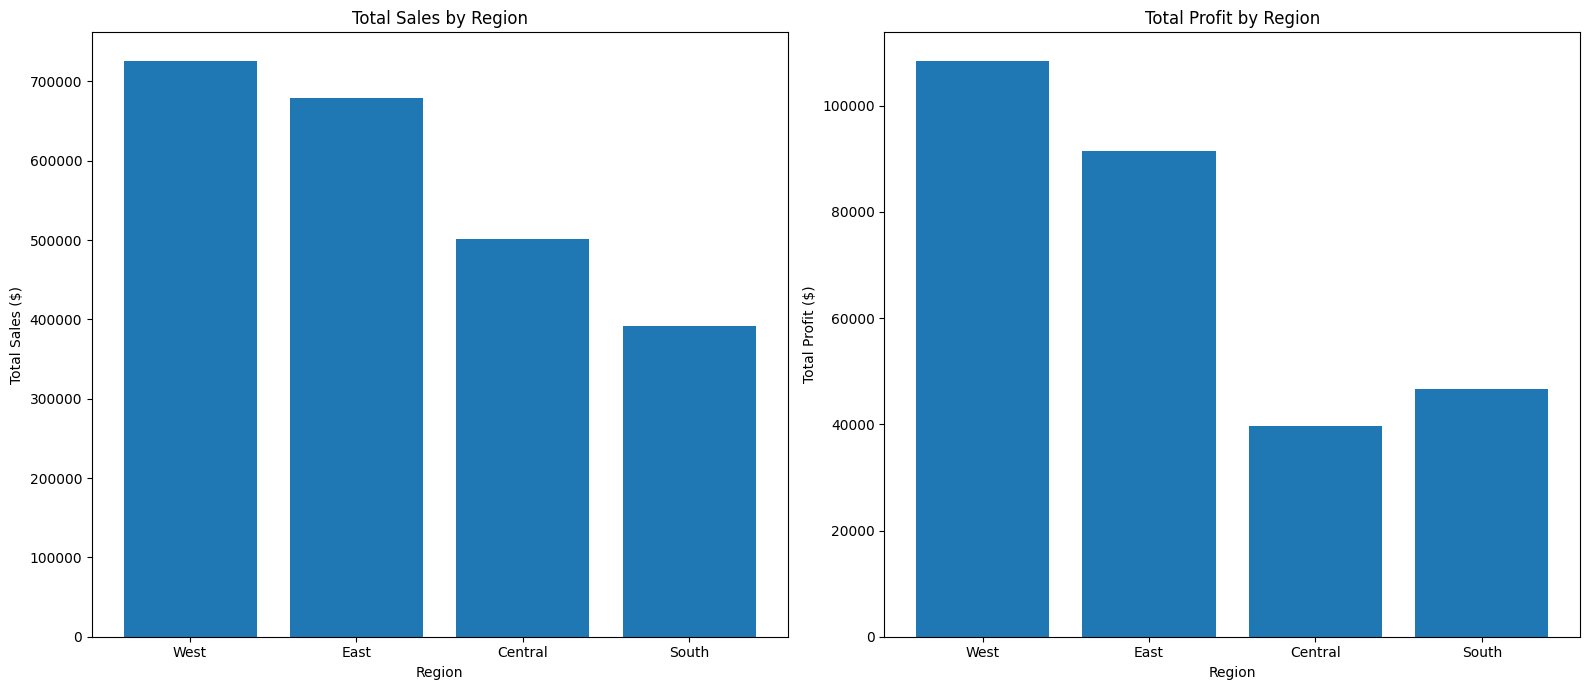

In [11]:
# create side-by-side bar plots for sales and profit by region
fig, ax =plt.subplots(1,2, figsize=(16,7))

# plot total sales by region
ax[0].bar(sales_by_region_sorted.index, sales_by_region_sorted['Sales'])
ax[0].set_title('Total Sales by Region')
ax[0].set_xlabel('Region')
ax[0].set_ylabel('Total Sales ($)')

# plot total profit by region
ax[1].bar(sales_by_region_sorted.index, sales_by_region_sorted['Profit'])
ax[1].set_title('Total Profit by Region')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
# plt.savefig('../reports/sales_and_profit_by_region.png', bbox_inches='tight', dpi=150)

### Intepretation
The bar charts show that the West had the highest records in sales (~$725K) and profit (~$108K). Meanwhile the South generated more profit (~$47K) than the Central region (~$40K) despite having lower sales (~$390K) compared to the Central region sales (~$500K). This suggests that pricing issues or mismanagement in the Central region may be possible causes.

## Is there a relationship between discount and profit?

Text(0.5, 1.0, 'Profit vs. Discount')

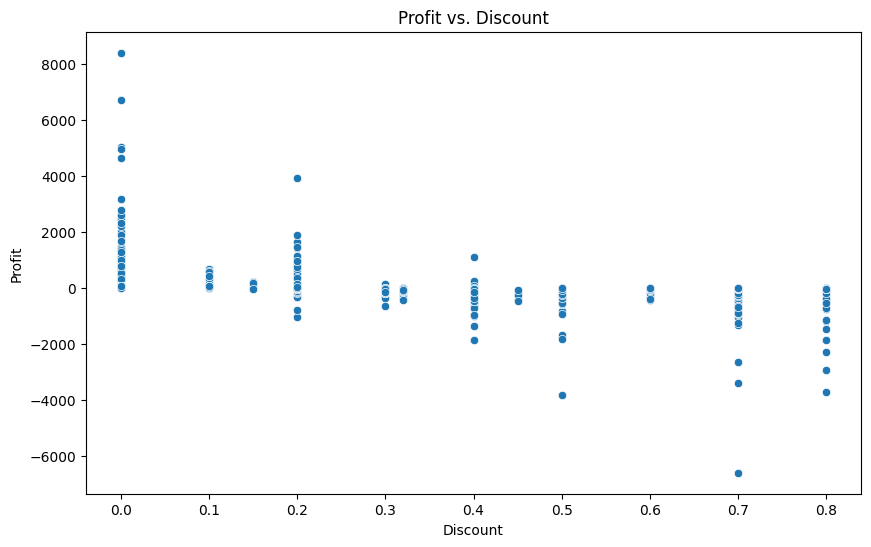

In [12]:
# create a scatter plot to visualize the relationship between discount and profit
plt.figure(figsize=(10,6))
sns.scatterplot(data=ss_df, x='Discount', y='Profit')

# tried a regplot but the fitted line was straight and not very informative
# sns.regplot(data=ss_df, x='Discount', y='Profit')

plt.title('Profit vs. Discount')
# plt.savefig('../reports/profit_vs_discount.png', bbox_inches='tight', dpi=150)

In [13]:
#calculate the correlation coefficient between discount and profit
discount_profit_corr = ss_df['Discount'].corr(ss_df['Profit'])
print(f'Correlation coefficient between Discount and Profit: {discount_profit_corr:.4f}') 

Correlation coefficient between Discount and Profit: -0.2195


### Interpretation
The scatter plot shows a spread of orders across different profit and discount levels, with orders with high discounts generating lower profits or losses, and orders with low or no discounts generating higher profits. However, there is no clear linear relationship between discount and profit.

The correlation coefficient of -0.2195 indicates a statistically weak negative correlation between discount and profit. This suggests that as discounts increase, profit tends to decrease slightly, but the relationship is not strong thus, other factors may also be influencing profit. 

Relating this back to the low profit generated by the Tables, Bookcases and Supplies sub-categories, despite their high sales, we saw that their profitability was very low. It is possible that these sub-categories had higher discounts applied to them, which could have contributed to their generating low profits or losses. Further analysis would be needed to confirm this hypothesis, such as calculating the average discount for each sub-category and comparing it to their profitability.

In [14]:
# calculate the average discount for each sub-category and compare it with the total profit for each sub-category
avg_discount_subcategory = ss_df.groupby('Sub-Category')[['Discount', 'Profit']].agg({'Discount':'mean', 'Profit': 'sum'}).round(2)
avg_discount_subcategory_sorted = avg_discount_subcategory.sort_values(by='Discount', ascending=False)
avg_discount_subcategory_sorted

,Discount,Profit
Sub-Category,,
Binders,0.37,30221.76
Machines,0.31,3384.76
Tables,0.26,-17725.48
Bookcases,0.21,-3472.56
Appliances,0.17,18138.01
Chairs,0.17,26590.17
Copiers,0.16,55617.82
Phones,0.15,44515.73
Furnishings,0.14,13059.14


In [15]:
# calculate the average discount for profitable orders (profit > 0) and unprofitable orders (profit <= 0)
avg_discount_profitable = ss_df[ss_df['Profit'] > 0]['Discount'].mean()
avg_discount_unprofitable = ss_df[ss_df['Profit'] <= 0]['Discount'].mean() 
print(f'Average discount for profitable orders: {avg_discount_profitable:.2f}')
print(f'Average discount for unprofitable orders: {avg_discount_unprofitable:.2f}')

Average discount for profitable orders: 0.08
Average discount for unprofitable orders: 0.47


### Interpretation of new findings
There is a wide gap between the average discount rate for profitable orders and that for unprofitable orders. 
From my earlier hypothesis, I expected Tables, Bookcases and Supplies to have the highest discount rates and Copiers, Phones and Accessories to have the lowest discount rates. I found that Binders followed by Machines had the highest discount rates while Paper and Storage had the lowest discount rates despite all four being profitable. The discount rates for Tables and Bookcases were moderately high (0.26 and 0.21) compared to that of Supplies (0.08) which suggests that there are other factors that affect the generated profit of the sub-categories such as pricing strategies or procurement and management costs. 

## How have sales trended over time?

In [16]:
# convert order date to datetime format and check the data type
ss_df['Order Date'] = pd.to_datetime(ss_df['Order Date'])
ss_df['Order Date'].dtype

# extract year and month from order date
ss_df['Order Month'] = ss_df['Order Date'].dt.to_period('M')

<Axes: title={'center': 'Total Sales by Month'}, xlabel='Order Month', ylabel='Total Sales ($)'>

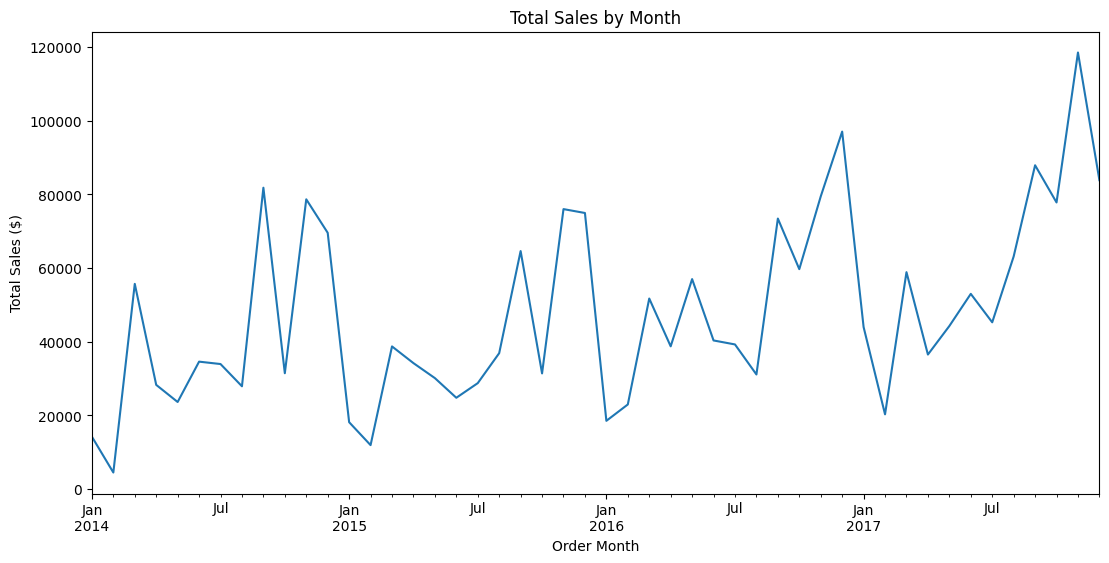

In [17]:
# group order date by sales to see if there are any seasonal trends
sales_by_month = ss_df.groupby('Order Month')['Sales'].sum()
sales_by_month.plot(kind='line', figsize=(13,6), title='Total Sales by Month', ylabel='Total Sales ($)')
# plt.savefig('../reports/sales_by_month.png', bbox_inches='tight', dpi=150)

### Interpretation  
 The line plot shows some seasonal trends in sales, with peaks around November and December, possibly due to holiday festivities and an increase on spending during holiday season. There is also a peak around March, which could be due to spring sales and also in September which could be due to back-to-school sales. The dip in sales around January and February could be due to post-holiday season slowdown and also in June and July which could be because of summer break and less shopping during summer. The overall trend shows an increase on general sales over time, which could be due to many factors such as business expansion and increased exposure though further analysis would be needed to determine the exact causes of these trends. But the seasonal trends remain fairly consistent and show there are certain times where sales are higher, which could be useful for future management and marketing strategies.